In [1]:
import json
import pandas as pd
import re

import re

In [ ]:
# Helper tools to prepare Paper results - Processing Ledger File
def parse_prediction(pred, Match_ID):
    if not pred:
        return None, None
        
    raw_score, raw_weight = None, None
    score, weight = None, None
    
    # 1. Extract the raw text based on how the agent formatted it
    if isinstance(pred, dict):
        raw_score = pred.get('Score', pred.get('score'))
        raw_weight = pred.get('Probability', pred.get('probability'))
    elif isinstance(pred, str):
        raw_score = pred 
        raw_weight = pred
        
    # 2. Extract, clean, and ORIENT the SCORE
    if raw_score and isinstance(raw_score, str):
        score_match = re.search(r'(\d+)\s*-\s*(\d+)', raw_score)
        if score_match:
            left_score, right_score = score_match.groups()
            
            # Context-Aware Flip Logic
            is_reversed = False
            if Match_ID and "-" in Match_ID:
                try:
                    home_team, away_team = Match_ID.split('-', 1)
                    home_team_lower = home_team.strip().lower()
                    away_team_lower = away_team.strip().lower()
                    raw_lower = raw_score.lower()
                    
                    idx_home = raw_lower.find(home_team_lower)
                    idx_away = raw_lower.find(away_team_lower)
                    
                    # If BOTH teams are mentioned in the string, check their order
                    if idx_home != -1 and idx_away != -1:
                        if idx_away < idx_home:
                            is_reversed = True
                except ValueError:
                    pass # Failsafe if Match_ID formatting is entirely unexpected
            
            # Apply the score format based on orientation
            if is_reversed:
                score = f"{right_score}-{left_score}"
            else:
                score = f"{left_score}-{right_score}"
            
    # 3. Extract and clean the WEIGHT (Odds or Probability)
    if raw_weight and isinstance(raw_weight, str):
        pct_match = re.search(r'([\d\.,]+%)', raw_weight)
        if pct_match:
            weight = pct_match.group(1).replace(',', '.')
        else:
            odds_match = re.search(r'\(([\d\.,]+)\)?\)?', raw_weight)
            if odds_match:
                weight = odds_match.group(1).replace(',', '.')
                
    return score, weight

def process_ledger_file(file_path):
    """
    Reads a JSONL text file line-by-line and flattens it into a pandas DataFrame.
    """
    rows = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
                
            data = json.loads(line)
            
            # 1. Base Metadata
            Match_ID = data.get('metadata', {}).get('match_id')
            row = {
                'Match_ID': Match_ID,
                'Timestamp': data.get('metadata', {}).get('timestamp_utc')
            }
            
            # 2. Consensus Oddsportal (Bookmaker)
            bm = data.get('bookmaker_baseline', {})
            for i in [1, 2, 3]:
                # Pass Match_ID to ensure correct orientation
                score, odds = parse_prediction(bm.get(f'Top_{i}'), Match_ID)
                row[f'Consensus_Top{i}_Score'] = score
                row[f'Consensus_Top{i}_Odds'] = odds
                
            # 3. Agent Pipelines (Agent C is intentionally excluded)
            agents = data.get('dag_pipeline', {})
            agent_mappings = [
                ('Agent_A_Quant', 'AgentA'),
                ('Agent_B_Qual', 'AgentB'),
                ('Agent_E_Meta', 'AgentE')
            ]
            
            for agent_key, prefix in agent_mappings:
                agent_data = agents.get(agent_key, {})
                for i in [1, 2, 3]:
                    # Pass Match_ID to ensure correct orientation
                    score, weight = parse_prediction(agent_data.get(f'Top_{i}'), Match_ID)
                    row[f'{prefix}_Top{i}_Score'] = score
                    row[f'{prefix}_Top{i}_Weight'] = weight
                    
            rows.append(row)
            
    return pd.DataFrame(rows)

In [ ]:
# Execute Helper tools to prepare Paper results --- EXECUTION and basic df creation --- Sanity Check before pushing to remote repostory

# Point this to the exact name/path of your file
file_name = "predictions_ledger.jsonl"

# Generate the DataFrame (all predictions model outputs, bookmakersdata for each match)
df = process_ledger_file(file_name)

# Display the first few columns to verify the cleaning worked
print(df.head())

# Optional: Export the cleaned DataFrame to a CSV or Excel file for easy viewing
df.to_csv("cleaned_predictions.csv", index=False)
# df.to_excel("cleaned_predictions.xlsx", index=False)

                   Match_ID                         Timestamp  \
0  Bosnia Herzegovina-Qatar  2026-06-24T18:22:07.560894+00:00   
1        Switzerland-Canada  2026-06-24T18:51:58.942081+00:00   
2           Scotland-Brazil  2026-06-24T19:11:19.721907+00:00   
3             Morocco-Haiti  2026-06-24T19:22:22.950009+00:00   
4     Czech Republic-Mexico  2026-06-24T19:36:16.089685+00:00   

  Consensus_Top1_Score Consensus_Top1_Odds Consensus_Top2_Score  \
0                  2-0                   8                  1-0   
1                  1-0                 8.1                  2-1   
2                  0-2                   6                  0-1   
3                  2-0                   6                  1-0   
4                  1-1                 7.5                  0-1   

  Consensus_Top2_Odds Consensus_Top3_Score Consensus_Top3_Odds  \
0                   9                  2-1                   9   
1                10.5                  2-0                12.5   
2       

In [ ]:
# Real Outcome of Matches
df.loc[df['Match_ID'] == 'Bosnia Herzegovina-Qatar', 'real_outcome'] = '3-1'
df.loc[df['Match_ID'] == 'Switzerland-Canada', 'real_outcome'] = '2-1'
df.loc[df['Match_ID'] == 'Scotland-Brazil', 'real_outcome'] = '0-3'
df.loc[df['Match_ID'] == 'Morocco-Haiti', 'real_outcome'] = '4-2'
df.loc[df['Match_ID'] == 'Czech Republic-Mexico', 'real_outcome'] = '0-3'
df.loc[df['Match_ID'] == 'South Africa-South Korea', 'real_outcome'] = '1-0'
df.loc[df['Match_ID'] == 'Curacao-Ivory Coast', 'real_outcome'] = '0-2'
df.loc[df['Match_ID'] == 'Equador-Germany', 'real_outcome'] = '2-1'
df.loc[df['Match_ID'] == 'Japan-Sweden', 'real_outcome'] = '1-1'
df.loc[df['Match_ID'] == 'Tunisia-Netherlands','real_outcome'] = '1-3'
df.loc[df['Match_ID'] == 'Paraguay-Australia', 'real_outcome'] = '0-0'
df.loc[df['Match_ID'] == 'Turkey-USA', 'real_outcome'] = '3-2'
df.loc[df['Match_ID'] == 'Norway-France', 'real_outcome'] = '1-4'
df.loc[df['Match_ID'] == 'Senegal-Iraq', 'real_outcome'] = '5-0' #13
df.loc[df['Match_ID'] == 'Cap Verde-Saudi Arabia', 'real_outcome'] = '0-0'
df.loc[df['Match_ID'] == 'Uruguay-Spain', 'real_outcome'] = '0-1'
df.loc[df['Match_ID'] == 'New Zealand-Belgium', 'real_outcome'] = '1-5'
df.loc[df['Match_ID'] == 'Egypt-Iran', 'real_outcome'] = '1-1'
df.loc[df['Match_ID'] == 'Croatia-Ghana', 'real_outcome'] = '2-1'
df.loc[df['Match_ID'] == 'Panama-England', 'real_outcome'] = '0-2'
df.loc[df['Match_ID'] == 'Columbia-Portugal', 'real_outcome'] = '0-0'
df.loc[df['Match_ID'] == 'DR Congo-Uzbekistan', 'real_outcome'] = '3-1' #21
df.loc[df['Match_ID'] == 'Algeria-Austria', 'real_outcome'] = '3-3'
df.loc[df['Match_ID'] == 'Jordan-Argentina', 'real_outcome'] = '1-3' #23
df.loc[df['Match_ID'] == 'South Africa-Canada', 'real_outcome'] = '0-1' #24##
df.loc[df['Match_ID'] == 'Brazil-Japan', 'real_outcome'] = '2-1'
df.loc[df['Match_ID'] == 'Germany-Paraguay', 'real_outcome'] = '1-1'
df.loc[df['Match_ID'] == 'Netherlands-Morocco', 'real_outcome'] = '1-1'
df.loc[df['Match_ID'] == 'Ivory Coast-Norway', 'real_outcome'] = '1-2'
df.loc[df['Match_ID'] == 'France-Sweden', 'real_outcome'] = '3-0'
df.loc[df['Match_ID'] == 'Mexiko-Equador', 'real_outcome'] = '2-0'
df.loc[df['Match_ID'] == 'England-DR Congo', 'real_outcome'] = '2-1'
df.loc[df['Match_ID'] == 'Belgium-Senegal', 'real_outcome'] = '2-2'
df.loc[df['Match_ID'] == 'USA-Bosnia & Herzegovina', 'real_outcome'] = '2-0'
df.loc[df['Match_ID'] == 'Spain-Austria', 'real_outcome'] = '3-0'
df.loc[df['Match_ID'] == 'Switzerland-Algeria', 'real_outcome'] = '2-0'
df.loc[df['Match_ID'] == 'Portugal-Croatia', 'real_outcome'] = '2-1'
df.loc[df['Match_ID'] == 'Australia-Egypt', 'real_outcome'] = '1-1'
df.loc[df['Match_ID'] == 'Argentina-Cap Verde', 'real_outcome'] = '1-1'
df.loc[df['Match_ID'] == 'Columbia-Ghana', 'real_outcome'] = '1-0'
df.loc[df['Match_ID'] == 'Canada-Morocco', 'real_outcome'] = '0-3'
df.loc[df['Match_ID'] == 'Paraguay-France', 'real_outcome'] = '0-1'
df.loc[df['Match_ID'] == 'Brazil-Norway', 'real_outcome'] = '1-2'
df.loc[df['Match_ID'] == 'Mexico-England', 'real_outcome'] = '2-3'
df.loc[df['Match_ID'] == 'Portugal-Spain', 'real_outcome'] = '0-1'
df.loc[df['Match_ID'] == 'USA-Belgium', 'real_outcome'] = '1-4'
df.loc[df['Match_ID'] == 'Switzerland-Columbia', 'real_outcome'] = '0-0'
df.loc[df['Match_ID'] == 'Argentina-Egypt', 'real_outcome'] = '3-2'
df.loc[df['Match_ID'] == 'France-Morocco', 'real_outcome'] = '2-0'
df.loc[df['Match_ID'] == 'Spain-Belgium', 'real_outcome'] = '2-1'
df.loc[df['Match_ID'] == 'Norway-England', 'real_outcome'] = '1-1'
df.loc[df['Match_ID'] == 'Argentina-Switzerland', 'real_outcome'] = '1-1'
df.loc[df['Match_ID'] == 'France-Spain', 'real_outcome'] = '0-2'
df.loc[df['Match_ID'] == 'England-Argentina', 'real_outcome'] = '1-2'
df.loc[df['Match_ID'] == 'France-England', 'real_outcome'] = '4-6'
df.loc[df['Match_ID'] == 'Spain-Argentina', 'real_outcome'] = '0-0'




In [ ]:
# Checking Column names
df.columns

Index(['Match_ID', 'Timestamp', 'Consensus_Top1_Score', 'Consensus_Top1_Odds',
       'Consensus_Top2_Score', 'Consensus_Top2_Odds', 'Consensus_Top3_Score',
       'Consensus_Top3_Odds', 'AgentA_Top1_Score', 'AgentA_Top1_Weight',
       'AgentA_Top2_Score', 'AgentA_Top2_Weight', 'AgentA_Top3_Score',
       'AgentA_Top3_Weight', 'AgentB_Top1_Score', 'AgentB_Top1_Weight',
       'AgentB_Top2_Score', 'AgentB_Top2_Weight', 'AgentB_Top3_Score',
       'AgentB_Top3_Weight', 'AgentE_Top1_Score', 'AgentE_Top1_Weight',
       'AgentE_Top2_Score', 'AgentE_Top2_Weight', 'AgentE_Top3_Score',
       'AgentE_Top3_Weight', 'real_outcome'],
      dtype='object')

In [ ]:
# ============================================================
# Table 1 - Measure 1: Main Analysis for Evaluation -> Top3 with Probability Weighted utility (PwU) and using correction factor for odds -> probabilities
# ============================================================
import pandas as pd
import numpy as np

def calculate_uefa_points(pred_score, real_score):
    """
    UEFA Predictor-derived scoring:
    +3 correct match result
    +1 correct home-team goals
    +1 correct away-team goals
    +1 correct goal difference
    Maximum = 6 points
    """
    if (
        pd.isna(pred_score)
        or pd.isna(real_score)
        or pred_score == 'Other'
        or real_score == 'Other'
    ):
        return 0

    try:
        pred_h, pred_a = map(int, str(pred_score).split('-'))
        real_h, real_a = map(int, str(real_score).split('-'))
    except ValueError:
        return 0

    points = 0

    # Correct result: home win / draw / away win
    if np.sign(pred_h - pred_a) == np.sign(real_h - real_a):
        points += 3

    # Correct home-team goal count
    if pred_h == real_h:
        points += 1

    # Correct away-team goal count
    if pred_a == real_a:
        points += 1

    # Correct goal difference
    if (pred_h - pred_a) == (real_h - real_a):
        points += 1

    return points

def parse_weight(weight_val):
    """Converts strings like '14.1%' to a decimal 0.141."""
    if pd.isna(weight_val):
        return 0.0
    if isinstance(weight_val, str) and '%' in weight_val:
        return float(weight_val.replace('%', '')) / 100.0
    return float(weight_val)

def parse_odds_to_prob(odds_val):
    """Converts decimal odds to implied probability, and taking into account correction e.g. of 1.1 (bookmakers odds do not behave like probabilities)."""
    if pd.isna(odds_val) or odds_val == 0:
        return 0.0
    try:
        return 1.0 / float(odds_val) / 1.12  #correction factor for odds ########################################
    except (ValueError, ZeroDivisionError):
        return 0.0

def calculate_agent_expected_score(row, agent_prefix):
    """Calculates the Probability-Weighted UEFA Score."""
    real = row.get('real_outcome')
    if pd.isna(real):
        return np.nan 
        
    total_expected_score = 0
    
    for i in range(1, 4):
        pred_col = f'{agent_prefix}_Top{i}_Score'
        pred = row.get(pred_col)
        points = calculate_uefa_points(pred, real)
        
        # Handle the difference between Consensus (Odds) and Agents (Weights)
        if agent_prefix == 'Consensus':
            odds_col = f'{agent_prefix}_Top{i}_Odds'
            odds_val = row.get(odds_col)
            probability = parse_odds_to_prob(odds_val)
        else:
            weight_col = f'{agent_prefix}_Top{i}_Weight'
            weight_val = row.get(weight_col)
            probability = parse_weight(weight_val)
        
        # Expected Value = Points * Probability
        total_expected_score += (points * probability)
        
    return total_expected_score

df['AgentA_Util_Prob'] = df.apply(lambda row: calculate_agent_expected_score(row, 'AgentA'), axis=1)
df['AgentB_Util_Prob'] = df.apply(lambda row: calculate_agent_expected_score(row, 'AgentB'), axis=1)
df['AgentE_Util_Prob'] = df.apply(lambda row: calculate_agent_expected_score(row, 'AgentE'), axis=1)
df['Bookmaker_Util_Prob'] = df.apply(lambda row: calculate_agent_expected_score(row, 'Consensus'), axis=1)
# Get Sum Scores
#df["column_name"].sum()
print("Agent A Sum:"+str(df['AgentA_Util_Prob'].sum()))
print("Agent B Sum:"+str(df['AgentB_Util_Prob'].sum())) 
print("Agent E Sum:"+str(df['AgentE_Util_Prob'].sum())) 
print("Bookmaker Sum:"+str(df['Bookmaker_Util_Prob'].sum()))  

Agent A Sum:56.51
Agent B Sum:59.712199999999996
Agent E Sum:57.6699
Bookmaker Sum:57.874731970444


In [ ]:

# ============================================================
# Table 1 Measure 2: Top-3 exact-score hit rate
# ============================================================
def calculate_top3_exact_hit(row, agent_prefix):
    """
    Returns 1 if the real exact score is contained in the agent's Top-3
    exact-score predictions, otherwise 0.
    """
    real = row.get('real_outcome')

    if pd.isna(real):
        return np.nan

    top3_predictions = [
        row.get(f'{agent_prefix}_Top1_Score'),
        row.get(f'{agent_prefix}_Top2_Score'),
        row.get(f'{agent_prefix}_Top3_Score')
    ]

    # Remove missing values
    top3_predictions = [
        str(pred) for pred in top3_predictions
        if not pd.isna(pred)
    ]

    return int(str(real) in top3_predictions)

# ============================================================
# Measure 3: Top-1 exact-score accuracy
# ============================================================
def calculate_top1_exact_accuracy(row, agent_prefix):
    """
    Returns 1 if the Top-1 exact-score prediction matches the real outcome,
    otherwise 0.
    """
    pred = row.get(f'{agent_prefix}_Top1_Score')
    real = row.get('real_outcome')

    if pd.isna(pred) or pd.isna(real):
        return np.nan

    return int(str(pred) == str(real))


df['AgentA_Top1_Exact'] = df.apply(
    lambda row: calculate_top1_exact_accuracy(row, 'AgentA'),
    axis=1
)

df['AgentB_Top1_Exact'] = df.apply(
    lambda row: calculate_top1_exact_accuracy(row, 'AgentB'),
    axis=1
)

df['AgentE_Top1_Exact'] = df.apply(
    lambda row: calculate_top1_exact_accuracy(row, 'AgentE'),
    axis=1
)

df['Consensus_Top1_Exact'] = df.apply(
    lambda row: calculate_top1_exact_accuracy(row, 'Consensus'),
    axis=1
)



df['AgentA_Top3_Exact_Hit'] = df.apply(
    lambda row: calculate_top3_exact_hit(row, 'AgentA'),
    axis=1
)

df['AgentB_Top3_Exact_Hit'] = df.apply(
    lambda row: calculate_top3_exact_hit(row, 'AgentB'),
    axis=1
)

df['AgentE_Top3_Exact_Hit'] = df.apply(
    lambda row: calculate_top3_exact_hit(row, 'AgentE'),
    axis=1
)

df['Consensus_Top3_Exact_Hit'] = df.apply(
    lambda row: calculate_top3_exact_hit(row, 'Consensus'),
    axis=1
)


# ============================================================
# Print total number of exact hits
# ============================================================

print("Top-1 exact-score hits:")
print("Agent A:", df['AgentA_Top1_Exact'].sum())
print("Agent B:", df['AgentB_Top1_Exact'].sum())
print("Agent E:", df['AgentE_Top1_Exact'].sum())
print("Consensus:", df['Consensus_Top1_Exact'].sum())


print("\nTop-3 exact-score hits:")
print("Agent A:", df['AgentA_Top3_Exact_Hit'].sum())
print("Agent B:", df['AgentB_Top3_Exact_Hit'].sum())
print("Agent E:", df['AgentE_Top3_Exact_Hit'].sum())
print("Consensus:", df['Consensus_Top3_Exact_Hit'].sum())


# ============================================================
# Print accuracy / hit rates
# ============================================================

print("\nTop-1 exact-score accuracy:")
print(
    "Agent A:",
    df['AgentA_Top1_Exact'].mean()
)
print(
    "Agent B:",
    df['AgentB_Top1_Exact'].mean()
)
print(
    "Agent E:",
    df['AgentE_Top1_Exact'].mean()
)
print(
    "Consensus:",
    df['Consensus_Top1_Exact'].mean()
)


print("\nTop-3 exact-score hit rate:")
print(
    "Agent A:",
    df['AgentA_Top3_Exact_Hit'].mean()
)
print(
    "Agent B:",
    df['AgentB_Top3_Exact_Hit'].mean()
)
print(
    "Agent E:",
    df['AgentE_Top3_Exact_Hit'].mean()
)
print(
    "Consensus:",
    df['Consensus_Top3_Exact_Hit'].mean()
)




Top-1 exact-score hits:
Agent A: 7
Agent B: 7
Agent E: 5
Consensus: 11

Top-3 exact-score hits:
Agent A: 20
Agent B: 23
Agent E: 18
Consensus: 23

Top-1 exact-score accuracy:
Agent A: 0.125
Agent B: 0.125
Agent E: 0.08928571428571429
Consensus: 0.19642857142857142

Top-3 exact-score hit rate:
Agent A: 0.35714285714285715
Agent B: 0.4107142857142857
Agent E: 0.32142857142857145
Consensus: 0.4107142857142857


In [ ]:
# ============================================================
#### Table 1 Measure 4 - Simple Top-1 UEfa utillity score
# ============================================================
def calculate_top1_uefa_score(row, agent_prefix):
    """
    Calculates the UEFA-derived utility for the single highest-ranked
    exact-score forecast (Top-1).

    Uses calculate_uefa_points(), which should implement:
    +3 correct match result
    +1 correct home-team goals
    +1 correct away-team goals
    +1 correct goal difference
    Maximum = 6 points
    """
    pred = row.get(f'{agent_prefix}_Top1_Score')
    real = row.get('real_outcome')

    return calculate_uefa_points(pred, real)

# Calculate Top-1 UEFA utility per match
df['AgentA_Top1_Utility'] = df.apply(
    lambda row: calculate_top1_uefa_score(row, 'AgentA'),
    axis=1
)

df['AgentB_Top1_Utility'] = df.apply(
    lambda row: calculate_top1_uefa_score(row, 'AgentB'),
    axis=1
)

df['AgentE_Top1_Utility'] = df.apply(
    lambda row: calculate_top1_uefa_score(row, 'AgentE'),
    axis=1
)

df['Consensus_Top1_Utility'] = df.apply(
    lambda row: calculate_top1_uefa_score(row, 'Consensus'),
    axis=1
)


# Overall scores
print(
    "Agent A Top-1 Utility:",
    df['AgentA_Top1_Utility'].sum()
)

print(
    "Agent B Top-1 Utility:",
    df['AgentB_Top1_Utility'].sum()
)

print(
    "Agent E Top-1 Utility:",
    df['AgentE_Top1_Utility'].sum()
)

print(
    "Consensus Top-1 Utility:",
    df['Consensus_Top1_Utility'].sum()
)


# Recommended for the paper: also report mean utility per match
print("\nMean Top-1 UEFA utility per match:")

print(
    "Agent A:",
    df['AgentA_Top1_Utility'].mean()
)

print(
    "Agent B:",
    df['AgentB_Top1_Utility'].mean()
)

print(
    "Agent E:",
    df['AgentE_Top1_Utility'].mean()
)

print(
    "Consensus:",
    df['Consensus_Top1_Utility'].mean()
)

Agent A Top-1 Utility: 174
Agent B Top-1 Utility: 152
Agent E Top-1 Utility: 153
Consensus Top-1 Utility: 180

Mean Top-1 UEFA utility per match:
Agent A: 3.107142857142857
Agent B: 2.7142857142857144
Agent E: 2.732142857142857
Consensus: 3.2142857142857144


In [9]:
# ============================================================
# Add Unconditional Prior (Fixed Random Guesser) based on footbool goal probabilities
# ============================================================

import numpy as np
import pandas as pd
from math import exp, factorial


# ------------------------------------------------------------
# 1. Literature-based Poisson parameter
# ------------------------------------------------------------

ALPHA = 2.5156
LAMBDA = ALPHA / 2

print(f"Total-goal parameter alpha: {ALPHA:.4f}")
print(f"Team-specific unconditional lambda: {LAMBDA:.4f}")


# ------------------------------------------------------------
# 2. Poisson probability
# ------------------------------------------------------------

def poisson_prob(k, lam):
    return exp(-lam) * (lam ** k) / factorial(k)


# ------------------------------------------------------------
# 3. Generate scoreline probability distribution
# ------------------------------------------------------------

score_probabilities = []

# 0-0 to 10-10 is more than sufficient for this lambda
for goals_1 in range(11):
    for goals_2 in range(11):

        probability = (
            poisson_prob(goals_1, LAMBDA)
            * poisson_prob(goals_2, LAMBDA)
        )

        score_probabilities.append(
            {
                "score": f"{goals_1}-{goals_2}",
                "probability": probability
            }
        )


score_probabilities = sorted(
    score_probabilities,
    key=lambda x: x["probability"],
    reverse=True
)


# Select Top-3
prior_top3 = score_probabilities[:3]


print("\nUnconditional football prior Top-3:")
for rank, item in enumerate(prior_top3, start=1):
    print(
        f"Top {rank}: "
        f"{item['score']} "
        f"({item['probability'] * 100:.2f}%)"
    )


# ------------------------------------------------------------
# 4. Add constant Top-3 predictions to every match
# ------------------------------------------------------------

for rank, item in enumerate(prior_top3, start=1):

    df[f"Prior_Top{rank}_Score"] = item["score"]
    df[f"Prior_Top{rank}_Weight"] = item["probability"]


# ------------------------------------------------------------
# 5. Probability-weighted Top-3 UEFA-derived utility
# ------------------------------------------------------------

def calculate_prior_probability_weighted_utility(row):

    real = row.get("real_outcome")

    if pd.isna(real):
        return np.nan

    total = 0.0

    for i in range(1, 4):

        pred = row[f"Prior_Top{i}_Score"]
        probability = row[f"Prior_Top{i}_Weight"]

        utility = calculate_uefa_points(
            pred,
            real
        )

        total += probability * utility

    return total


df["Prior_Util_Prob"] = df.apply(
    calculate_prior_probability_weighted_utility,
    axis=1
)


# ------------------------------------------------------------
# 6. Top-3 exact hit
# ------------------------------------------------------------

def calculate_prior_top3_exact_hit(row):

    real = row.get("real_outcome")

    if pd.isna(real):
        return np.nan

    predictions = [
        row["Prior_Top1_Score"],
        row["Prior_Top2_Score"],
        row["Prior_Top3_Score"]
    ]

    return int(str(real) in predictions)


df["Prior_Top3_Exact_Hit"] = df.apply(
    calculate_prior_top3_exact_hit,
    axis=1
)


# ------------------------------------------------------------
# 7. Top-1 UEFA-derived utility
# ------------------------------------------------------------

def calculate_prior_top1_utility(row):

    real = row.get("real_outcome")

    if pd.isna(real):
        return np.nan

    return calculate_uefa_points(
        row["Prior_Top1_Score"],
        real
    )


df["Prior_Top1_Utility"] = df.apply(
    calculate_prior_top1_utility,
    axis=1
)


# ------------------------------------------------------------
# 8. Top-1 exact-score accuracy
# ------------------------------------------------------------

def calculate_prior_top1_exact(row):

    real = row.get("real_outcome")

    if pd.isna(real):
        return np.nan

    return int(
        str(row["Prior_Top1_Score"]) == str(real)
    )


df["Prior_Top1_Exact"] = df.apply(
    calculate_prior_top1_exact,
    axis=1
)



Total-goal parameter alpha: 2.5156
Team-specific unconditional lambda: 1.2578

Unconditional football prior Top-3:
Top 1: 1-1 (12.79%)
Top 2: 0-1 (10.16%)
Top 3: 1-0 (10.16%)


In [ ]:
# ============================================================
# Table 1 - Calculating and summarizing results 
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# Helper functions
# ============================================================

def format_mean_sd(series, decimals=3):
    """
    Formats a numeric metric as:
    mean (SD)

    Example:
    1.066 (0.412)
    """
    valid = pd.to_numeric(series, errors='coerce').dropna()

    if len(valid) == 0:
        return "NA"

    mean_val = valid.mean()
    sd_val = valid.std(ddof=1)   # sample standard deviation

    return f"{mean_val:.{decimals}f} ({sd_val:.{decimals}f})"


def format_exact_metric(series):
    """
    Formats a binary exact-score metric as:
    n/N (xx.x%)
    """
    valid = pd.to_numeric(series, errors='coerce').dropna()

    if len(valid) == 0:
        return "NA"

    hits = int(valid.sum())
    N = len(valid)
    percentage = (hits / N) * 100

    return f"{hits}/{N} ({percentage:.1f}%)"


# ============================================================
# Check required baseline columns
# ============================================================

prior_columns = [
    "Prior_Util_Prob",
    "Prior_Top3_Exact_Hit",
    "Prior_Top1_Utility",
    "Prior_Top1_Exact"
]

missing_prior_columns = [
    col for col in prior_columns
    if col not in df.columns
]

if missing_prior_columns:
    raise KeyError(
        "The unconditional football prior has not yet been calculated. "
        "Missing columns: "
        + ", ".join(missing_prior_columns)
    )


# ============================================================
# Construct publication-style summary table
# ============================================================

summary_table = pd.DataFrame([

    # --------------------------------------------------------
    # Quantitative agent
    # --------------------------------------------------------
    {
        "Forecaster": "Quantitative agent (A)",

        "Top-3 probability-weighted utility, mean (SD)":
            format_mean_sd(df["AgentA_Util_Prob"]),

        "Top-3 exact hit, n/N (%)":
            format_exact_metric(df["AgentA_Top3_Exact_Hit"]),

        "Top-1 UEFA-derived utility, mean (SD)":
            format_mean_sd(df["AgentA_Top1_Utility"]),

        "Top-1 exact accuracy, n/N (%)":
            format_exact_metric(df["AgentA_Top1_Exact"])
    },

    # --------------------------------------------------------
    # News agent
    # --------------------------------------------------------
    {
        "Forecaster": "News agent (B)",

        "Top-3 probability-weighted utility, mean (SD)":
            format_mean_sd(df["AgentB_Util_Prob"]),

        "Top-3 exact hit, n/N (%)":
            format_exact_metric(df["AgentB_Top3_Exact_Hit"]),

        "Top-1 UEFA-derived utility, mean (SD)":
            format_mean_sd(df["AgentB_Top1_Utility"]),

        "Top-1 exact accuracy, n/N (%)":
            format_exact_metric(df["AgentB_Top1_Exact"])
    },

    # --------------------------------------------------------
    # Meta-agent
    # --------------------------------------------------------
    {
        "Forecaster": "Meta-agent (E)",

        "Top-3 probability-weighted utility, mean (SD)":
            format_mean_sd(df["AgentE_Util_Prob"]),

        "Top-3 exact hit, n/N (%)":
            format_exact_metric(df["AgentE_Top3_Exact_Hit"]),

        "Top-1 UEFA-derived utility, mean (SD)":
            format_mean_sd(df["AgentE_Top1_Utility"]),

        "Top-1 exact accuracy, n/N (%)":
            format_exact_metric(df["AgentE_Top1_Exact"])
    },

    # --------------------------------------------------------
    # Betting market
    # --------------------------------------------------------
    {
        "Forecaster": "Betting market",

        "Top-3 probability-weighted utility, mean (SD)":
            format_mean_sd(df["Bookmaker_Util_Prob"]),

        "Top-3 exact hit, n/N (%)":
            format_exact_metric(df["Consensus_Top3_Exact_Hit"]),

        "Top-1 UEFA-derived utility, mean (SD)":
            format_mean_sd(df["Consensus_Top1_Utility"]),

        "Top-1 exact accuracy, n/N (%)":
            format_exact_metric(df["Consensus_Top1_Exact"])
    },

    # --------------------------------------------------------
    # Unconditional football prior
    # --------------------------------------------------------
    {
        "Forecaster": "Unconditional football prior",

        "Top-3 probability-weighted utility, mean (SD)":
            format_mean_sd(df["Prior_Util_Prob"]),

        "Top-3 exact hit, n/N (%)":
            format_exact_metric(df["Prior_Top3_Exact_Hit"]),

        "Top-1 UEFA-derived utility, mean (SD)":
            format_mean_sd(df["Prior_Top1_Utility"]),

        "Top-1 exact accuracy, n/N (%)":
            format_exact_metric(df["Prior_Top1_Exact"])
    }

])


# ============================================================
# Print table
# ============================================================

print("\nMain forecasting performance table\n")
print(summary_table.to_string(index=False))




Main forecasting performance table

                  Forecaster Top-3 probability-weighted utility, mean (SD) Top-3 exact hit, n/N (%) Top-1 UEFA-derived utility, mean (SD) Top-1 exact accuracy, n/N (%)
      Quantitative agent (A)                                 1.009 (0.537)            20/56 (35.7%)                         3.107 (1.836)                  7/56 (12.5%)
              News agent (B)                                 1.066 (0.588)            23/56 (41.1%)                         2.714 (2.025)                  7/56 (12.5%)
              Meta-agent (E)                                 1.030 (0.580)            18/56 (32.1%)                         2.732 (1.892)                   5/56 (8.9%)
              Betting market                                 1.033 (0.559)            23/56 (41.1%)                         3.214 (2.078)                 11/56 (19.6%)
Unconditional football prior                                 0.607 (0.196)            14/56 (25.0%)                        

In [34]:
# Additional Anaylsis: Calculate Probability Mass as Counter-Measure for Probability Inflation in PwU
# ============================================================
# Top-3 probability mass by forecaster
# Mean (SD)
# ============================================================

import pandas as pd
import numpy as np


def to_probability(x):
    """Convert percentage strings or numeric values to probability scale."""
    if pd.isna(x):
        return np.nan

    if isinstance(x, str):
        x = x.strip()
        if x.endswith("%"):
            return float(x[:-1]) / 100
        x = float(x)

    x = float(x)
    return x / 100 if x > 1 else x


# ------------------------------------------------------------
# Agents
# ------------------------------------------------------------

for p in ["AgentA", "AgentB", "AgentE"]:
    df[f"{p}_Top3_Mass"] = sum(
        df[f"{p}_Top{k}_Weight"].apply(to_probability)
        for k in [1, 2, 3]
    )


# ------------------------------------------------------------
# Betting market
# Same 1.12 overround correction as primary PWU
# ------------------------------------------------------------

df["Market_Top3_Mass"] = sum(
    (1 / pd.to_numeric(df[f"Consensus_Top{k}_Odds"], errors="coerce")) / 1.12
    for k in [1, 2, 3]
)


# ------------------------------------------------------------
# Unconditional football prior
# ------------------------------------------------------------

df["Prior_Top3_Mass"] = sum(
    df[f"Prior_Top{k}_Weight"].apply(to_probability)
    for k in [1, 2, 3]
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

mass_columns = {
    "Quantitative agent (A)": "AgentA_Top3_Mass",
    "News agent (B)": "AgentB_Top3_Mass",
    "Meta-agent (E)": "AgentE_Top3_Mass",
    "Betting market": "Market_Top3_Mass",
    "Unconditional football prior": "Prior_Top3_Mass",
}

print("Top-3 probability mass, mean (SD)\n")

for name, col in mass_columns.items():
    x = pd.to_numeric(df[col], errors="coerce").dropna()

    print(
        f"{name}: "
        f"{x.mean():.3f} ({x.std(ddof=1):.3f})"
    )

Top-3 probability mass, mean (SD)

Quantitative agent (A): 0.382 (0.060)
News agent (B): 0.386 (0.061)
Meta-agent (E): 0.393 (0.082)
Betting market: 0.359 (0.052)
Unconditional football prior: 0.331 (0.000)


In [11]:
# ============================================================
# Table 1 - HTML output of final forecasting performance table
# Includes unconditional football prior baseline
# ============================================================

from IPython.display import display, HTML


# ------------------------------------------------------------
# Shorter publication-style column names
# ------------------------------------------------------------

word_table = summary_table.rename(columns={

    "Top-3 probability-weighted utility, mean (SD)":
        "Top-3 weighted utility, mean (SD)",

    "Top-3 exact hit, n/N (%)":
        "Top-3 exact hit, n/N (%)",

    "Top-1 UEFA-derived utility, mean (SD)":
        "Top-1 utility, mean (SD)",

    "Top-1 exact accuracy, n/N (%)":
        "Top-1 exact accuracy, n/N (%)"
})


# ------------------------------------------------------------
# Render as HTML table
# -> can be copied directly into Word
# ------------------------------------------------------------

display(
    HTML(
        word_table.to_html(
            index=False,
            border=1,
            justify="center"
        )
    )
)

Forecaster,"Top-3 weighted utility, mean (SD)","Top-3 exact hit, n/N (%)","Top-1 utility, mean (SD)","Top-1 exact accuracy, n/N (%)"
Quantitative agent (A),1.009 (0.537),20/56 (35.7%),3.107 (1.836),7/56 (12.5%)
News agent (B),1.066 (0.588),23/56 (41.1%),2.714 (2.025),7/56 (12.5%)
Meta-agent (E),1.030 (0.580),18/56 (32.1%),2.732 (1.892),5/56 (8.9%)
Betting market,1.033 (0.559),23/56 (41.1%),3.214 (2.078),11/56 (19.6%)
Unconditional football prior,0.607 (0.196),14/56 (25.0%),1.768 (2.123),8/56 (14.3%)


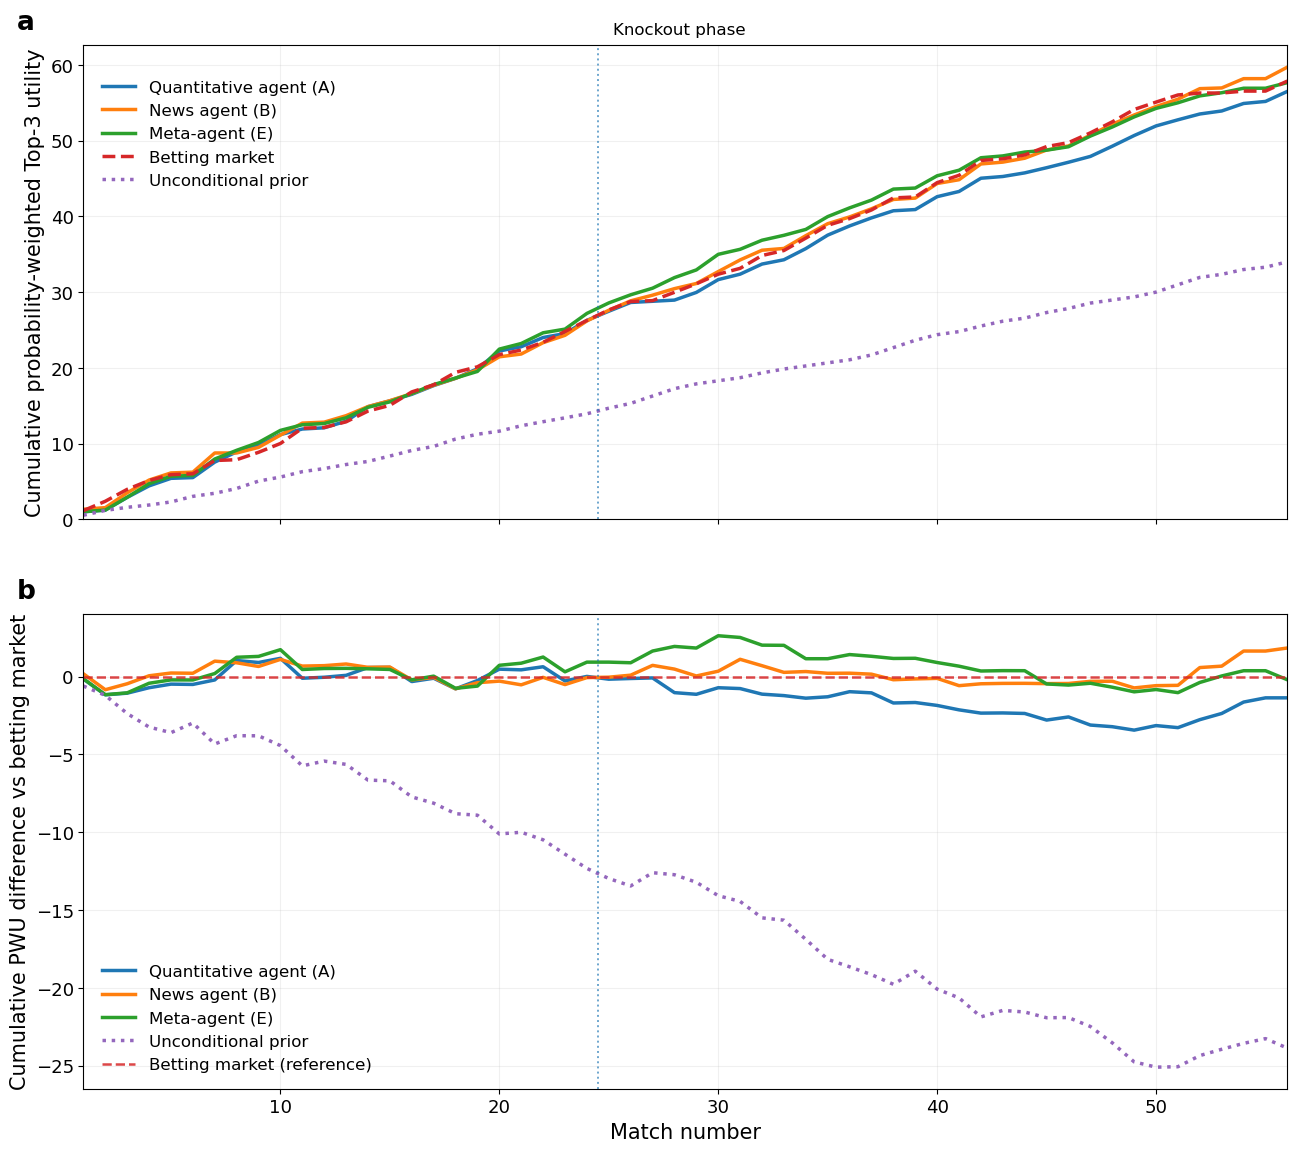

In [27]:
# ============================================================
# Figure 2 - Cumulative forecasting performance
#
# a) Cumulative probability-weighted Top-3 utility
# b) Cumulative PWU difference vs betting market
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

plot_df = df.reset_index(drop=True).copy()
plot_df["Match_Number"] = np.arange(1, len(plot_df) + 1)

utility_columns = {
    "Quantitative agent (A)": "AgentA_Util_Prob",
    "News agent (B)": "AgentB_Util_Prob",
    "Meta-agent (E)": "AgentE_Util_Prob",
    "Betting market": "Bookmaker_Util_Prob",
    "Unconditional prior": "Prior_Util_Prob",
}

for name, col in utility_columns.items():
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    if plot_df[col].isna().any():
        raise ValueError(f"Missing/non-numeric values found in {col}")

    plot_df[f"{col}_Cumulative"] = plot_df[col].cumsum()


# ------------------------------------------------------------
# 2. Consistent colors and line styles
# ------------------------------------------------------------

cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

colors = {
    "Quantitative agent (A)": cycle[0],
    "News agent (B)": cycle[1],
    "Meta-agent (E)": cycle[2],
    "Betting market": cycle[3],
    "Unconditional prior": cycle[4],
}

styles = {
    "Quantitative agent (A)": "-",
    "News agent (B)": "-",
    "Meta-agent (E)": "-",
    "Betting market": "--",
    "Unconditional prior": ":",
}


# ------------------------------------------------------------
# 3. Create vertically stacked figure
# ------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 12),
    sharex=True
)


# ============================================================
# PANEL a - Absolute cumulative utility
# ============================================================

for name, col in utility_columns.items():
    ax1.plot(
        plot_df["Match_Number"],
        plot_df[f"{col}_Cumulative"],
        color=colors[name],
        linestyle=styles[name],
        linewidth=2.5,
        label=name
    )

ax1.set_ylabel(
    "Cumulative probability-weighted Top-3 utility",
    fontsize=15
)

ax1.set_xlim(1, len(plot_df))
ax1.set_ylim(bottom=0)

ax1.tick_params(
    axis="both",
    labelsize=13
)

ax1.grid(
    True,
    alpha=0.18,
    linewidth=0.8
)

# Panel label
ax1.text(
    -0.055,
    1.02,
    "a",
    transform=ax1.transAxes,
    fontsize=19,
    fontweight="bold",
    ha="left",
    va="bottom",
    clip_on=False
)

# Legend
ax1.legend(
    frameon=False,
    fontsize=12,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.94),
    borderaxespad=0
)

# Boundary: first 24 evaluated matches = final group-stage round
ax1.axvline(
    x=24.5,
    linestyle=":",
    linewidth=1.4,
    alpha=0.65
)

# Label only in panel a
ax1.text(
    25.2,
    1.015,
    "Knockout phase",
    transform=ax1.get_xaxis_transform(),
    ha="left",
    va="bottom",
    fontsize=12,
    clip_on=False
)


# ============================================================
# PANEL b - Cumulative PWU difference vs betting market
# ============================================================

market_col = "Bookmaker_Util_Prob"

difference_columns = {
    "Quantitative agent (A)": "AgentA_Util_Prob",
    "News agent (B)": "AgentB_Util_Prob",
    "Meta-agent (E)": "AgentE_Util_Prob",
    "Unconditional prior": "Prior_Util_Prob",
}

for name, col in difference_columns.items():

    cumulative_difference = (
        plot_df[col] - plot_df[market_col]
    ).cumsum()

    ax2.plot(
        plot_df["Match_Number"],
        cumulative_difference,
        color=colors[name],
        linestyle=styles[name],
        linewidth=2.5,
        label=name
    )

# Betting market = zero reference
ax2.axhline(
    y=0,
    color=colors["Betting market"],
    linestyle="--",
    linewidth=1.8,
    alpha=0.85,
    label="Betting market (reference)"
)

ax2.set_xlabel(
    "Match number",
    fontsize=15
)

ax2.set_ylabel(
    "Cumulative PWU difference vs betting market",
    fontsize=15
)

ax2.set_xlim(1, len(plot_df))

ax2.tick_params(
    axis="both",
    labelsize=13
)

ax2.grid(
    True,
    alpha=0.18,
    linewidth=0.8
)

# Panel label
ax2.text(
    -0.055,
    1.02,
    "b",
    transform=ax2.transAxes,
    fontsize=19,
    fontweight="bold",
    ha="left",
    va="bottom",
    clip_on=False
)

# Separate legend because panel b represents differences
ax2.legend(
    frameon=False,
    fontsize=12,
    loc="lower left",
    bbox_to_anchor=(0.01, 0.02),
    borderaxespad=0
)

# Same tournament boundary, but no repeated phase label
ax2.axvline(
    x=24.5,
    linestyle=":",
    linewidth=1.4,
    alpha=0.65
)


# ------------------------------------------------------------
# 4. Layout
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.95,
    bottom=0.08,
    hspace=0.20
)


# ------------------------------------------------------------
# 5. Export
# ------------------------------------------------------------

plt.savefig(
    "Figure2_cumulative_PWU_vertical.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure2_cumulative_PWU_vertical.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [13]:
df.columns

Index(['Match_ID', 'Timestamp', 'Consensus_Top1_Score', 'Consensus_Top1_Odds',
       'Consensus_Top2_Score', 'Consensus_Top2_Odds', 'Consensus_Top3_Score',
       'Consensus_Top3_Odds', 'AgentA_Top1_Score', 'AgentA_Top1_Weight',
       'AgentA_Top2_Score', 'AgentA_Top2_Weight', 'AgentA_Top3_Score',
       'AgentA_Top3_Weight', 'AgentB_Top1_Score', 'AgentB_Top1_Weight',
       'AgentB_Top2_Score', 'AgentB_Top2_Weight', 'AgentB_Top3_Score',
       'AgentB_Top3_Weight', 'AgentE_Top1_Score', 'AgentE_Top1_Weight',
       'AgentE_Top2_Score', 'AgentE_Top2_Weight', 'AgentE_Top3_Score',
       'AgentE_Top3_Weight', 'real_outcome', 'AgentA_Util_Prob',
       'AgentB_Util_Prob', 'AgentE_Util_Prob', 'Bookmaker_Util_Prob',
       'AgentA_Top1_Exact', 'AgentB_Top1_Exact', 'AgentE_Top1_Exact',
       'Consensus_Top1_Exact', 'AgentA_Top3_Exact_Hit',
       'AgentB_Top3_Exact_Hit', 'AgentE_Top3_Exact_Hit',
       'Consensus_Top3_Exact_Hit', 'AgentA_Top1_Utility',
       'AgentB_Top1_Utility', 'AgentE

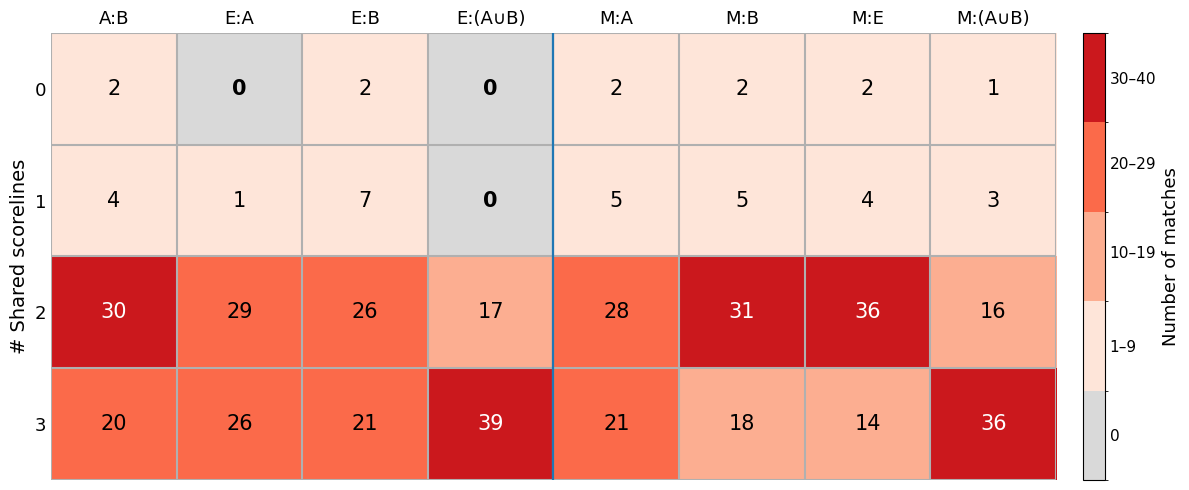

In [32]:
# ============================================================
# Heatmap - Exact Top-3 scoreline overlap
# Categorical red scale
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm


def raw_triple(row,p):
    return [
        row[f"{p}_Top1_Score"],
        row[f"{p}_Top2_Score"],
        row[f"{p}_Top3_Score"],
    ]


# ------------------------------------------------------------
# 1. Calculate overlap distributions
# ------------------------------------------------------------

rows=[]

for _,row in df.iterrows():

    A=set(raw_triple(row,"AgentA"))
    B=set(raw_triple(row,"AgentB"))
    E=set(raw_triple(row,"AgentE"))
    M=set(raw_triple(row,"Consensus"))

    rows.append({
        "A:B":len(A&B),
        "E:A":len(E&A),
        "E:B":len(E&B),
        "E:(A∪B)":len(E&(A|B)),
        "M:A":len(M&A),
        "M:B":len(M&B),
        "M:E":len(M&E),
        "M:(A∪B)":len(M&(A|B)),
    })

ov=pd.DataFrame(rows)

heat=pd.DataFrame(index=[0,1,2,3])

for c in ov.columns:
    heat[c]=(
        ov[c]
        .value_counts()
        .reindex([0,1,2,3],fill_value=0)
    )


# ------------------------------------------------------------
# 2. Categorical colour scale
#
# 0      = distinct neutral category
# 1-9    = very light red
# 10-19  = light red
# 20-29  = medium red
# 30-40  = strong red
# ------------------------------------------------------------

colors = [
    "#d9d9d9",  # 0
    "#fee5d9",  # 1-9
    "#fcae91",  # 10-19
    "#fb6a4a",  # 20-29
    "#cb181d",  # 30-40
]

cmap = ListedColormap(colors)

bounds = [
    -0.5,
    0.5,
    9.5,
    19.5,
    29.5,
    40.5
]

norm = BoundaryNorm(
    bounds,
    cmap.N
)


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------

fig,ax=plt.subplots(
    figsize=(12,5)
)

im=ax.imshow(
    heat.values,
    aspect="auto",
    cmap=cmap,
    norm=norm
)


# ------------------------------------------------------------
# 4. Cell values
# ------------------------------------------------------------

for i in range(heat.shape[0]):

    for j in range(heat.shape[1]):

        value=heat.iloc[i,j]

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold" if value==0 else "normal",
            color="white" if value>=30 else "black"
        )


# ------------------------------------------------------------
# 5. Axes
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(len(heat.columns))
)

ax.set_xticklabels(
    heat.columns,
    fontsize=13
)

ax.set_yticks(
    np.arange(4)
)

ax.set_yticklabels(
    [0,1,2,3],
    fontsize=13
)

ax.set_ylabel(
    "# Shared scorelines",
    fontsize=14
)

ax.tick_params(
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    length=0
)


# ------------------------------------------------------------
# 6. Separate agent and market comparisons
# ------------------------------------------------------------

ax.axvline(
    3.5,
    linewidth=1.6
)


# ------------------------------------------------------------
# 7. Cell borders
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(-0.5,len(heat.columns),1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5,4,1),
    minor=True
)

ax.grid(
    which="minor",
    linewidth=1.5
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

for spine in ax.spines.values():
    spine.set_visible(False)


# ------------------------------------------------------------
# 8. Categorical color bar
# ------------------------------------------------------------

cbar=fig.colorbar(
    im,
    ax=ax,
    fraction=0.025,
    pad=0.025,
    boundaries=bounds,
    ticks=[0,5,15,25,35]
)

cbar.ax.set_yticklabels([
    "0",
    "1–9",
    "10–19",
    "20–29",
    "30–40"
])

cbar.set_label(
    "Number of matches",
    fontsize=13
)

cbar.ax.tick_params(
    labelsize=11,
    length=0
)


# ------------------------------------------------------------
# 9. Export
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "Figure_scoreline_overlap_heatmap.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure_scoreline_overlap_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [15]:
import pandas as pd

# ============================================================
# Possible outcoem deviations of Meta compared to A∪B
# ============================================================

def raw_triple(row, p):
    return [
        row[f"{p}_Top1_Score"],
        row[f"{p}_Top2_Score"],
        row[f"{p}_Top3_Score"],
    ]

def calculate_uefa_points(pred, actual):
    ph, pa = map(int, pred.split("-"))
    ah, aa = map(int, actual.split("-"))

    pred_result = (ph > pa) - (ph < pa)
    actual_result = (ah > aa) - (ah < aa)

    return (
        3 * (pred_result == actual_result)
        + (ph == ah)
        + (pa == aa)
        + ((ph - pa) == (ah - aa))
    )


# ------------------------------------------------------------
# 1. Empirical possibility space
# ------------------------------------------------------------

cand = set()

for _, row in df.iterrows():
    for p in ("AgentA", "AgentB", "AgentE", "Consensus", "Prior"):
        cand.update(raw_triple(row, p))

cand = sorted(cand)

print(f"Possibility space: {len(cand)} distinct scorelines\n")


# ------------------------------------------------------------
# 2. Opportunity and actual Meta deviation
# ------------------------------------------------------------

rows = []

for _, row in df.iterrows():

    A = set(raw_triple(row, "AgentA"))
    B = set(raw_triple(row, "AgentB"))
    E = raw_triple(row, "AgentE")
    union = A | B

    # Similarity of all empirically observed candidate scorelines
    # to the closest scoreline in Quant ∪ News
    candidate_sim = [
        max(calculate_uefa_points(c, u) for u in union)
        for c in cand
    ]

    # Similarity of each Meta prediction to Quant ∪ News
    meta_sim = [
        max(calculate_uefa_points(e, u) for u in union)
        for e in E
    ]

    rows.append({
        "Match_ID": row["Match_ID"],
        "E": E,
        "union": sorted(union),
        "possible": any(s < 2 for s in candidate_sim),
        "deviated": any(s < 2 for s in meta_sim),
        "s1": meta_sim[0],
        "s2": meta_sim[1],
        "s3": meta_sim[2],
    })

poss = pd.DataFrame(rows)

n = len(poss)
n_possible = int(poss["possible"].sum())
n_deviated = int(poss["deviated"].sum())
n_took = int((poss["possible"] & poss["deviated"]).sum())

print(
    f"Outcome-level departure available: "
    f"{n_possible}/{n} ({100*n_possible/n:.1f}%)"
)

print(
    f"Meta outcome-level departure: "
    f"{n_deviated}/{n} ({100*n_deviated/n:.1f}%)"
)

print(
    f"Meta deviated when departure was available: "
    f"{n_took}/{n_possible} ({100*n_took/n_possible:.1f}%)"
)


# ------------------------------------------------------------
# 3. PWU in actual deviation matches
# ------------------------------------------------------------

dev_ids = poss.loc[poss["deviated"], "Match_ID"]

cols = [
    "Match_ID",
    "real_outcome",
    "AgentA_Util_Prob",
    "AgentB_Util_Prob",
    "AgentE_Util_Prob",
]

d = df[df["Match_ID"].isin(dev_ids)][cols].copy()


def classify(e, a, b):
    if e > max(a, b):
        return "better"
    if e < min(a, b):
        return "worse"
    return "between"


d["PWU_class"] = [
    classify(
        r.AgentE_Util_Prob,
        r.AgentA_Util_Prob,
        r.AgentB_Util_Prob
    )
    for r in d.itertuples()
]

d = d.merge(
    poss[["Match_ID", "E", "union", "s1", "s2", "s3"]],
    on="Match_ID"
)

print(
    f"\n=== {len(d)} OUTCOME-LEVEL DEVIATION MATCHES ==="
)

print(
    d[[
        "Match_ID",
        "real_outcome",
        "E",
        "union",
        "AgentA_Util_Prob",
        "AgentB_Util_Prob",
        "AgentE_Util_Prob",
        "PWU_class",
    ]].to_string(index=False)
)

print("\nPWU classification:")
print(d["PWU_class"].value_counts().to_string())


# ------------------------------------------------------------
# 4. Non-deviation reference
# ------------------------------------------------------------

rest = df[~df["Match_ID"].isin(dev_ids)]

rest_cls = [
    classify(
        r.AgentE_Util_Prob,
        r.AgentA_Util_Prob,
        r.AgentB_Util_Prob
    )
    for r in rest.itertuples()
]

print(f"\n=== {len(rest)} NON-DEVIATION MATCHES ===")
print(pd.Series(rest_cls).value_counts().to_string())

print(
    f"\nMeta better than both specialists: "
    f"{d['PWU_class'].value_counts().get('better', 0)}/{len(d)} deviation matches "
    f"vs {rest_cls.count('better')}/{len(rest)} non-deviation matches"
)

Possibility space: 13 distinct scorelines

Outcome-level departure available: 41/56 (73.2%)
Meta outcome-level departure: 6/56 (10.7%)
Meta deviated when departure was available: 6/41 (14.6%)

=== 6 OUTCOME-LEVEL DEVIATION MATCHES ===
                Match_ID real_outcome               E                          union  AgentA_Util_Prob  AgentB_Util_Prob  AgentE_Util_Prob PWU_class
         Scotland-Brazil          0-3 [0-1, 0-2, 0-0]                [0-1, 0-2, 0-3]            1.6800            1.9560            1.6910   between
     Curacao-Ivory Coast          0-2 [0-1, 0-2, 0-0]                [0-1, 0-2, 0-3]            2.0436            2.5320            2.1669   between
            Senegal-Iraq          5-0 [1-0, 2-0, 0-0]           [1-0, 2-0, 2-1, 3-0]            1.9188            1.2023            1.3872   between
       Columbia-Portugal          0-0 [1-1, 0-1, 1-0] [0-1, 0-2, 0-3, 0-4, 1-1, 1-2]            0.5619            0.3670            0.7400    better
USA-Bosnia & Herzego